## Fase 2.1 — Mes de menor volumen por año

**Objetivo:** para cada año, identificar qué mes tuvo el menor volumen
exportado (en USD y en toneladas) — primer paso para ver si existe un
patrón de "pausa" estacional consistente entre años.

**Fuente:** `data/processed/chaco_serie_mensual_2002_2026.csv`

---

In [2]:
import os
os.chdir('..')

In [3]:
import pandas as pd

df = pd.read_csv('data/processed/chaco_serie_mensual_2002_2026.csv', parse_dates=['fecha'])

serie_mensual = (
    df.groupby('fecha')[['FOB_dólar', 'Peso neto']]
    .sum()
    .sort_index()
)
serie_mensual['Año'] = serie_mensual.index.year
serie_mensual['Mes'] = serie_mensual.index.month

# Para cada año, buscamos la fila con el menor valor en USD
mes_minimo_usd = serie_mensual.loc[serie_mensual.groupby('Año')['FOB_dólar'].idxmin()]
mes_minimo_usd = mes_minimo_usd[['Año', 'Mes', 'FOB_dólar']].set_index('Año')

# Y lo mismo para toneladas
mes_minimo_ton = serie_mensual.loc[serie_mensual.groupby('Año')['Peso neto'].idxmin()]
mes_minimo_ton = mes_minimo_ton[['Año', 'Mes', 'Peso neto']].set_index('Año')

# Juntamos ambas, para los años recientes (2021-2026, foco del proyecto)
resumen_minimos = mes_minimo_usd.join(mes_minimo_ton, lsuffix='_usd', rsuffix='_ton')
resumen_minimos.loc[2021:2026]

,Mes_usd,FOB_dólar,Mes_ton,Peso neto
Año,,,,
2021,2,13736621.90,2,3.434278e+07
2022,12,23180074.29,12,5.468080e+07
2023,1,14463798.33,1,3.773955e+07
2024,2,11481099.49,2,2.461160e+07
2025,1,14197343.27,3,3.473268e+07
2026,1,21205885.20,6,4.874490e+07


**Observación:** en la mayoría de los años (2021, 2023, 2024, 2025, 2026),
el mes de menor volumen cayó en enero o febrero — señal de un patrón
estacional consistente al arranque del año. La excepción es **2022**
(piso en diciembre), a revisar más adelante.

Además, en 2025 y 2026 el mes más bajo en USD no coincide con el más bajo
en toneladas — en 2026 particularmente, el piso en toneladas fue **junio**,
el mismo mes que ya se había marcado como atípico en la Fase 1.8 (variación
interanual negativa en volumen mientras el valor en dólares seguía
creciendo). Ambas observaciones son consistentes entre sí.

## Fase 2.2 — Coeficiente de variación mensual por año

**Objetivo:** medir, con un solo número por año, qué tan pareja o
irregular fue la distribución mensual de exportaciones — un coeficiente
alto indica estacionalidad marcada (meses muy distintos entre sí); uno
bajo indica un año más uniforme.

**Fórmula:** desvío estándar de los 12 meses / promedio de los 12 meses.

---

In [4]:
# Coeficiente de variación por año, en USD
cv_por_año = (
    serie_mensual.groupby('Año')['FOB_dólar']
    .agg(['std', 'mean'])
)
cv_por_año['coef_variacion'] = cv_por_año['std'] / cv_por_año['mean']

cv_por_año.loc[2021:2026, ['coef_variacion']].round(3)

,coef_variacion
Año,
2021,0.394
2022,0.317
2023,0.282
2024,0.237
2025,0.165
2026,0.134


**Observación:** el coeficiente de variación baja de forma sostenida año
tras año (0,394 en 2021 → 0,134 en 2026), sugiriendo que Chaco exporta
de forma cada vez más pareja a lo largo del año, no solo distinta en
volumen total. **Matiz:** 2026 solo tiene 6 meses de datos, y con menos
observaciones el coeficiente tiende a salir más bajo — antes de afirmar
que 2026 es "el año más uniforme", hace falta comparar en igualdad de
condiciones (ver 2.3).

## Fase 2.3 — Coeficiente de variación, primer semestre (comparación entre años)

**Objetivo:** repetir el cálculo del 2.2, pero usando únicamente los
primeros 6 meses de cada año (2021-2026) — así 2026 se compara en
igualdad de condiciones contra años completos, sin el sesgo de tener
menos observaciones.

---

In [5]:
# Mismo cálculo que el 2.2, pero filtrando solo enero-junio de cada año
primer_semestre = serie_mensual[serie_mensual['Mes'] <= 6]

cv_semestre = (
    primer_semestre.groupby('Año')['FOB_dólar']
    .agg(['std', 'mean'])
)
cv_semestre['coef_variacion_H1'] = cv_semestre['std'] / cv_semestre['mean']

cv_semestre.loc[2021:2026, ['coef_variacion_H1']].round(3)

,coef_variacion_H1
Año,
2021,0.426
2022,0.180
2023,0.270
2024,0.320
2025,0.131
2026,0.134


**Conclusión:** al comparar en igualdad de condiciones (solo primer
semestre), la tendencia lineal decreciente del 2.2 **no se sostiene** —
2022 (0,180) es más bajo que 2023 (0,270) y 2024 (0,320), rompiendo la
progresión aparente. Sí se confirma que **2025 y 2026 tienen los
semestres más parejos** de toda la serie reciente (0,131 y 0,134), pero
no como parte de una tendencia gradual, sino como un cambio más marcado
en esos dos últimos años. El coeficiente de variación del 2.2 original
estaba parcialmente inflado por comparar años de distinta longitud.

## Fase 2.4 — Índice de estacionalidad

**Objetivo:** para cada mes de cada año, calcular qué tan por encima o
por debajo estuvo del promedio de ese mismo año (base 100 = promedio
anual). Permite comparar el mismo mes calendario entre distintos años
(ej. "julio 2026 vs. julio histórico").

**Fórmula:** (valor del mes / promedio del año) × 100

---

In [6]:
indice_estacional = serie_mensual.copy()

# Promedio anual, calculado por año
promedio_anual = indice_estacional.groupby('Año')['FOB_dólar'].transform('mean')

indice_estacional['indice_USD'] = (indice_estacional['FOB_dólar'] / promedio_anual) * 100

# Vista: años recientes, ordenados por mes para comparar entre años
tabla_indice = indice_estacional.loc[
    indice_estacional['Año'].between(2021, 2026),
    ['Año', 'Mes', 'indice_USD']
].pivot(index='Mes', columns='Año', values='indice_USD')

tabla_indice.round(1)

Año,2021,2022,2023,2024,2025,2026
Mes,,,,,,
1,41.4,72.3,57.1,78.0,72.5,83.7
2,39.3,66.4,79.8,63.8,86.5,95.9
3,66.8,78.4,89.3,102.5,76.7,111.5
4,90.1,90.5,76.1,91.8,86.7,98.1
5,111.5,103.3,127.9,136.9,103.4,120.0
6,111.5,101.3,94.9,148.2,94.5,90.8
7,136.6,132.2,103.4,115.4,108.6,NaN
8,164.4,109.5,143.6,90.9,110.2,NaN
9,151.0,130.7,132.2,102.6,112.2,NaN


## Fase 2.5-2.6 — Gráfico: índice de estacionalidad, todos los años superpuestos

**Objetivo:** visualizar los 12 meses de cada año (índice de
estacionalidad, base 100 = promedio anual), con una banda de rango
histórico (2021-2025) y 2026 destacado — para ver si el patrón mensual
de 2026 se parece a lo normal o se distingue.

**Nota:** 2026 solo tiene 6 meses de datos disponibles (hasta junio).

---

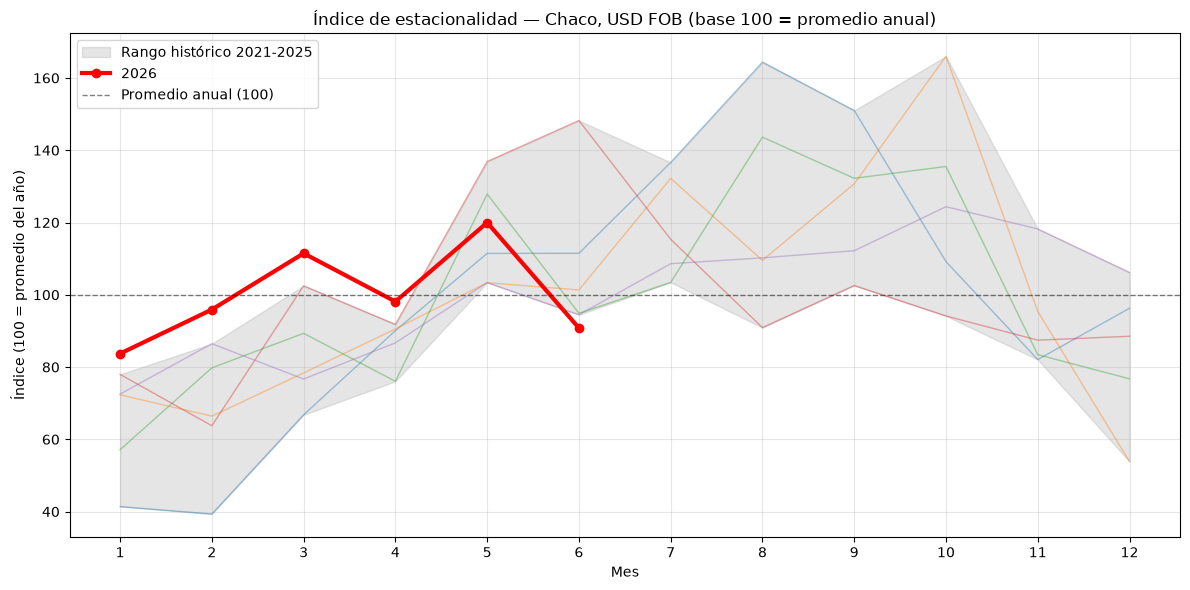

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Rango histórico 2021-2025: banda sombreada entre mínimo y máximo de cada mes
historico = tabla_indice[[2021, 2022, 2023, 2024, 2025]]
ax.fill_between(
    historico.index,
    historico.min(axis=1),
    historico.max(axis=1),
    alpha=0.2, color='gray', label='Rango histórico 2021-2025'
)

# Cada año histórico, como línea fina
for año in [2021, 2022, 2023, 2024, 2025]:
    ax.plot(tabla_indice.index, tabla_indice[año], alpha=0.4, linewidth=1)

# 2026, destacado
ax.plot(tabla_indice.index, tabla_indice[2026], color='red', linewidth=3, marker='o', label='2026')

ax.axhline(100, color='black', linestyle='--', alpha=0.5, linewidth=1, label='Promedio anual (100)')

ax.set_title('Índice de estacionalidad — Chaco, USD FOB (base 100 = promedio anual)')
ax.set_xlabel('Mes')
ax.set_ylabel('Índice (100 = promedio del año)')
ax.set_xticks(range(1, 13))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusión:** el gráfico confirma, de forma visual, lo que ya se venía
viendo en pasos anteriores. Enero-mayo 2026 se mantiene consistentemente
en la zona alta de la banda histórica (2021-2025), incluso por encima del
promedio anual (índice > 100) en marzo y mayo — un comportamiento inusual
para el arranque del año, que históricamente suele estar por debajo de
100 (ver Fase 2.1). Esto sugiere que 2026 no solo exportó más en términos
absolutos, sino que **redistribuyó su propio patrón estacional**, con
menos "pausa" al inicio del año.

**Junio 2026 rompe esa racha**, cayendo cerca del límite inferior de la
banda — cuarta señal (junto con 1.8, 2.1 y esta) de una desaceleración
puntual en ese mes. **Matiz metodológico:** como el índice se calcula
sobre el promedio del propio año, y 2026 tiene solo 6 meses (todos
relativamente altos), la caída de junio puede verse más pronunciada de
lo que se vería con 12 meses de referencia — la dirección del hallazgo
es real, pero la magnitud exacta hay que tomarla con cautela hasta tener
el año completo.